### Optimizing Classic Benchmark Functions using Particle Swarm Optimization (PSO)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import os

In [14]:
#--- Sphere function (minimize) ---#
def sphere(x):
    return np.sum(np.square(x))


#--- Rosenbrock function (minimize) ---#
def rosenbrock(x):
    total = 0
    for i in range(len(x) - 1):
        part1 = 100*(x[i+1] - x[i]**2)**2
        part2 = (1-x[i])**2
        total += (part1 + part2)

    return total


#--- Rastrigin function (minimize) ---#
def rastrigin(x):
    total = 10 * len(x) + np.sum(np.square(x) - 10 * np.cos(2 * np.pi * x))
    return total


#--- Ackley function (minimize) ---#
def ackley(x):
    n = len(x)
    part1 = -20*np.exp(-0.2*np.sqrt(1/n*np.sum(np.square(x))))
    part2 = -np.exp(1/n * np.sum(np.cos(2*np.pi*x)))
    return part1 + part2 + 20 + np.exp(1)

In [15]:
#--- Main ---#
class Particle:
    def __init__(self, bounds):
        self.num_dimensions = len(bounds)
        self.bounds = bounds
        self.position_i = np.array([np.random.uniform(b[0], b[1]) for b in bounds])  # Current position
        range_size = [b[1] - b[0] for b in bounds]
        self.velocity_i = np.array([np.random.uniform(-0.2*r, 0.2*r) for r in range_size])  # Current velocity
        self.pos_best_i = np.copy(self.position_i)  # Best known position of this particle
        self.err_best_i = np.inf  # Best known fitness of this particle
        self.err_i = np.inf       # Current fitness


    def evaluate (self, costFunc):
        self.err_i = costFunc(self.position_i)
        if self.err_i < self.err_best_i:
            self.pos_best_i = np.copy(self.position_i)
            self.err_best_i = self.err_i


    def update_velocity(self, pos_best_g, inertia_weight=0.7, cognitive_coef=1.5, social_coef=1.5):
        r1 = np.random.random(self.num_dimensions)
        r2 = np.random.random(self.num_dimensions)
        inertia = inertia_weight * self.velocity_i

        cognitive = cognitive_coef * r1 * (self.pos_best_i - self.position_i)
        social = social_coef * r2 * (pos_best_g - self.position_i)
        self.velocity_i = inertia + cognitive + social

        v_max = np.array([0.5 * (b[1] - b[0]) for b in self.bounds])
        self.velocity_i = np.clip(self.velocity_i, -v_max, v_max)


    def update_position(self):
        for i in range(0, self.num_dimensions):
            self.position_i[i] += self.velocity_i[i]

            if self.position_i[i] > self.bounds[i][1]:
                self.position_i[i] = self.bounds[i][1]

            if self.position_i[i] < self.bounds[i][0]:
                self.position_i[i] = self.bounds[i][0]

In [16]:
#--- PSO Loop ---#

class PSO():
    def __init__(self, costFunc, bounds, num_particles=30, max_iterations=300,
                 inertia_weight=0.7, cognitive_coef=1.5, social_coef=1.5, local=False):
        self.costFunc = costFunc
        self.bounds = bounds
        self.num_particles = num_particles
        self.max_iterations = max_iterations
        self.inertia_weight = inertia_weight
        self.cognitive_coef = cognitive_coef
        self.social_coef = social_coef
        self.err_best_g = np.inf
        self.pos_best_g = None
        self.local = local

    def run(self):
        swarm = [Particle(self.bounds) for _ in range(self.num_particles)]
        best_curve = []
        
        for iteration in range(self.max_iterations):
            for particle in swarm:
                particle.evaluate(self.costFunc)
                if particle.err_i < self.err_best_g:
                    self.pos_best_g = np.copy(particle.position_i)
                    self.err_best_g = particle.err_i
            
            best_curve.append(self.err_best_g)

            for idx, particle in enumerate(swarm):
                if self.local == True:
                    left = (idx - 2) % self.num_particles
                    right = (idx + 2) % self.num_particles
                    neighborhood = [swarm[left], swarm[idx], swarm[right]]
                    best_local_particle = min(neighborhood, key=lambda p: p.err_best_i)
                    pos_best_local = np.copy(best_local_particle.pos_best_i)

                    particle.update_velocity(pos_best_local, self.inertia_weight, self.cognitive_coef, self.social_coef)
                
                else:
                    particle.update_velocity(self.pos_best_g, self.inertia_weight, self.cognitive_coef, self.social_coef)
                
                particle.update_position()

            #--- Early stopping condition ---#
            func_name = self.costFunc.__name__.lower()
            if (func_name in ['sphere', 'rosenbrock'] and self.err_best_g < 1e-8) or \
                (func_name in ['rastrigin', 'ackley'] and self.err_best_g < 1e-4):
                #print(f"Stopping early at iteration {iteration} ({func_name})")
                break

            #if iteration == self.max_iterations - 1:
                #print("Maximum number of iterations reached")

        #print("Best position:", self.pos_best_g)
        #print("Best fitness:", self.err_best_g)
        evals = len(best_curve) * self.num_particles
        return self.pos_best_g, self.err_best_g, best_curve, evals



In [17]:
def compare_functions(results, functions, dimensions, save=False):
    os.makedirs("plots", exist_ok=True)

    plt.figure(figsize=(7,5))
    for f in functions:
        curves = results[f]["curves"]
        max_len = max(len(c) for c in curves)
        padded = np.array([np.pad(c, (0, max_len - len(c)), 'edge') for c in curves])
        plt.plot(np.mean(padded, axis=0), label=f)
    plt.title("PSO Convergence Comparison")
    plt.xlabel("Iteration")
    plt.ylabel("Mean best fitness (log scale)")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)

    if save:
        path = os.path.join("plots", f"pso_convergence_comparison_{dimensions}D.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Saved: {path}")
    plt.show()


def plot_final_fitness_boxplots(results, dimensions, output_dir="plots", save=False):
    """Boxplots of final best fitness across all runs for each benchmark function."""
    os.makedirs(output_dir, exist_ok=True)

    data = []
    labels = []
    for f in results.keys():
        finals = [curve[-1] for curve in results[f]["curves"]]
        data.append(finals)
        labels.append(f)

    plt.figure(figsize=(8, 5))
    plt.boxplot(data, labels=labels, showmeans=True)
    plt.yscale("log")
    plt.title(f"Final Fitness Across 30 Runs ({dimensions}-D)")
    plt.ylabel("Final Best Fitness (log scale)")
    plt.grid(True, alpha=0.6)

    if save:
        path = os.path.join(output_dir, f"final_fitness_boxplot_{dimensions}D.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Saved: {path}")

    plt.show()


def plot_convergence_summary(results, function_name):
    """Show single-run and mean convergence curves side by side."""
    curves = results[function_name]["curves"]
    max_len = max(len(c) for c in curves)

    # Pad shorter runs (for consistent array shape)
    padded = np.array([np.pad(c, (0, max_len - len(c)), 'edge') for c in curves])
    mean_curve = np.mean(padded, axis=0)
    std_curve = np.std(padded, axis=0)

    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # --- Left: Single run convergence ---
    axes[0].plot(curves[0])
    axes[0].set_title(f"Single Run – {function_name}")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Best fitness (gbest)")
    axes[0].set_yscale("log")
    axes[0].grid(True)

    # --- Right: Mean ± Std convergence ---
    axes[1].plot(mean_curve, label="Mean gbest")
    axes[1].fill_between(range(max_len),
                         mean_curve - std_curve,
                         mean_curve + std_curve,
                         color="gray", alpha=0.3, label="±1 Std Dev")
    axes[1].set_title(f"Mean Convergence – {function_name}")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Best fitness (gbest)")
    axes[1].set_yscale("log")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()



def parameter_study(functions, configs, num_dimensions=10, num_runs=30):
    results = {}

    for costFunc in functions:
        print(f"\nParameter Study – {costFunc.__name__} (n={num_dimensions})")
        if costFunc == rosenbrock:
            bounds = np.array([(-5, 10) for _ in range(num_dimensions)])
        elif costFunc == rastrigin:
            bounds = np.array([(-5.12, 5.12) for _ in range(num_dimensions)])
        elif costFunc == ackley:
            bounds = np.array([(-32.768, 32.768) for _ in range(num_dimensions)])
        else:
            bounds = np.array([(-5.12, 5.12) for _ in range(num_dimensions)])
        func_results = []

        for (omega, c1, c2) in configs:
            fitnesses = []
            for _ in range(num_runs):
                pso = PSO(costFunc, bounds, num_particles=30,
                          inertia_weight=omega, cognitive_coef=c1, social_coef=c2)
                _, best_fit, _, _ = pso.run()
                fitnesses.append(best_fit)

            # Record statistics for this parameter set
            func_results.append({
                "omega": omega,
                "c1": c1,
                "c2": c2,
                "mean": np.mean(fitnesses),
                "std": np.std(fitnesses),
                "best": np.min(fitnesses),
                "worst": np.max(fitnesses)
            })

            #print(f"(ω={omega}, c1={c1}, c2={c2}) → "
             #     f"mean={np.mean(fitnesses):.3e}, std={np.std(fitnesses):.3e}")

        # Store per-function results
        results[costFunc.__name__] = func_results

    return results


def plot_parameter_study(results, save=False, output_dir="plots"):
    """
    Visualize mean fitness across different (ω, c1, c2) settings
    for each benchmark function.
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    for func_name, configs in results.items():
        omegas = [r["omega"] for r in configs]
        means = [r["mean"] for r in configs]
        stds = [r["std"] for r in configs]
        labels = [f"ω={r['omega']}, c1={r['c1']}, c2={r['c2']}" for r in configs]

        plt.figure(figsize=(8, 5))
        plt.bar(range(len(configs)), means, yerr=stds, capsize=5, color='steelblue', alpha=0.8)
        plt.xticks(range(len(configs)), labels, rotation=25, ha='right')
        plt.yscale("log")
        plt.ylabel("Mean Final Fitness (log scale)")
        plt.title(f"Parameter Study Results – {func_name}")
        plt.grid(axis="y", alpha=0.4)

        if save:
            path = os.path.join(output_dir, f"param_study_{func_name}.png")
            plt.savefig(path, dpi=300, bbox_inches="tight")
            print(f"Saved: {path}")

        plt.show()




def compare_lbest_gbest(costFunc, bounds, num_particles=30, max_iterations=300,
                        inertia_weight=0.7, cognitive_coef=1.5, social_coef=1.5,
                        num_runs=10, output_dir="plots", save=False):
    """
    Compare convergence between local-best (lbest) and global-best (gbest) PSO.

    Parameters:
        costFunc: objective function
        bounds: np.array of variable bounds [(lower, upper), ...]
        num_particles: swarm size
        max_iterations: max iterations per run
        inertia_weight, cognitive_coef, social_coef: PSO parameters
        num_runs: number of independent runs for averaging
        output_dir: directory to save plots
        save: whether to save figure
    """

    os.makedirs(output_dir, exist_ok=True)
    print(f"Comparing lbest vs gbest on {costFunc.__name__}...")

    # --- Run global-best (standard PSO) ---
    from copy import deepcopy

    gbest_curves = []
    for _ in range(num_runs):
        pso_g = PSO(costFunc=costFunc, bounds=deepcopy(bounds),
                    num_particles=num_particles, max_iterations=max_iterations,
                    inertia_weight=inertia_weight, cognitive_coef=cognitive_coef,
                    social_coef=social_coef, local=False)
        _, _, curve_g, _ = pso_g.run()
        gbest_curves.append(curve_g)

    # --- Run local-best variant (ring topology) ---
    lbest_curves = []
    for _ in range(num_runs):
        pso_l = PSO(costFunc=costFunc, bounds=deepcopy(bounds),
                    num_particles=num_particles, max_iterations=max_iterations,
                    inertia_weight=inertia_weight, cognitive_coef=cognitive_coef,
                    social_coef=social_coef, local=True)
        _, _, curve_l, _ = pso_l.run()
        lbest_curves.append(curve_l)

    # --- Prepare curves (pad to equal length) ---
    max_len = max(max(len(c) for c in gbest_curves), max(len(c) for c in lbest_curves))
    pad = lambda c: np.pad(c, (0, max_len - len(c)), 'edge')
    gbest_curves = np.array([pad(c) for c in gbest_curves])
    lbest_curves = np.array([pad(c) for c in lbest_curves])

    gbest_mean, gbest_std = np.mean(gbest_curves, axis=0), np.std(gbest_curves, axis=0)
    lbest_mean, lbest_std = np.mean(lbest_curves, axis=0), np.std(lbest_curves, axis=0)

    # --- Plot ---
    plt.figure(figsize=(7, 5))
    plt.plot(gbest_mean, label="Global Best (gbest)", color="tab:blue")
    plt.fill_between(range(max_len), gbest_mean - gbest_std, gbest_mean + gbest_std,
                     color="tab:blue", alpha=0.2)
    plt.plot(lbest_mean, label="Local Best (lbest)", color="tab:orange")
    plt.fill_between(range(max_len), lbest_mean - lbest_std, lbest_mean + lbest_std,
                     color="tab:orange", alpha=0.2)

    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Best fitness")
    plt.title(f"Global vs Local Best PSO Comparison – {costFunc.__name__}")
    plt.legend()
    plt.grid(True)

    if save:
        path = os.path.join(output_dir, f"gbest_vs_lbest_{costFunc.__name__}.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Saved: {path}")

    plt.show()


In [18]:
def run_experimental(num_runs=30, num_dimensions=2, local=False):
    results = {}

    functions = [sphere, rosenbrock, rastrigin, ackley]

    for costFunc in functions:
        print(f"\nFunction: {costFunc.__name__}, Dimensions: {num_dimensions}, Runs: {num_runs}, Local: {local}")
        if costFunc == rosenbrock:
            bounds = np.array([(-5, 10) for _ in range(num_dimensions)])
        elif costFunc == rastrigin:
            bounds = np.array([(-5.12, 5.12) for _ in range(num_dimensions)])
        elif costFunc == ackley:
            bounds = np.array([(-32.768, 32.768) for _ in range(num_dimensions)])
        else:
            bounds = np.array([(-5.12, 5.12) for _ in range(num_dimensions)])

        fitnesses, all_curves, evaluations = [], [], []
        start_time = time.time()

        for _ in range(num_runs):
            n_particles = 50 if num_dimensions == 30 else 30
            pso = PSO(costFunc=costFunc, bounds=bounds, num_particles=n_particles, local=local)
            best_pos, best_fit, best_curve, evals = pso.run()
            fitnesses.append(best_fit)
            evaluations.append(evals)
            all_curves.append(best_curve)


        runtime = time.time() - start_time
        success_threshold = 1e-8 if costFunc in [sphere, rosenbrock] else 1e-4
        success_rate = np.mean(np.array(fitnesses) <= success_threshold)

        results[costFunc.__name__] = {
            "mean": np.mean(fitnesses),
            "median": np.median(fitnesses),
            "std": np.std(fitnesses),
            "best": np.min(fitnesses),
            "worst": np.max(fitnesses),
            "success_rate": success_rate,
            "mean_evaluations": np.mean(evaluations),
            "runtime_sec": runtime,
            "curves": all_curves,
            "fitnesses": fitnesses
        }

        print(f"→ mean: {np.mean(fitnesses):.3e}, std: {np.std(fitnesses):.3e}, "
              f"best: {np.min(fitnesses):.3e}, worst: {np.max(fitnesses):.3e}, "
              f"success_rate: {success_rate*100:.2f}, time: {runtime:.2f}s")

        plot_convergence_summary(results, costFunc.__name__)
        if costFunc == ackley:
            print("\n\n")

    return results

### Run the experiment


Function: sphere, Dimensions: 2, Runs: 30, Local: False
→ mean: 4.677e-09, std: 2.720e-09, best: 1.541e-11, worst: 9.570e-09, success_rate: 100.00, time: 0.60s


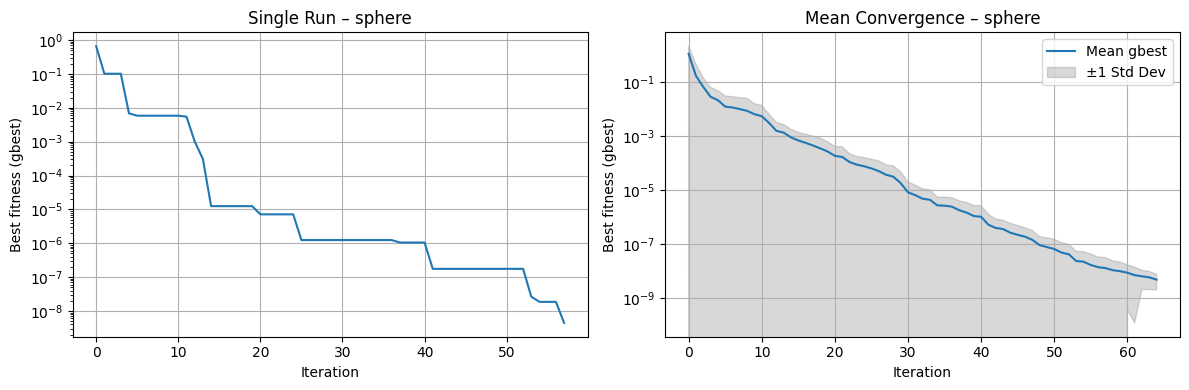


Function: rosenbrock, Dimensions: 2, Runs: 30, Local: False
→ mean: 6.462e-09, std: 2.553e-09, best: 2.062e-10, worst: 9.882e-09, success_rate: 100.00, time: 2.01s


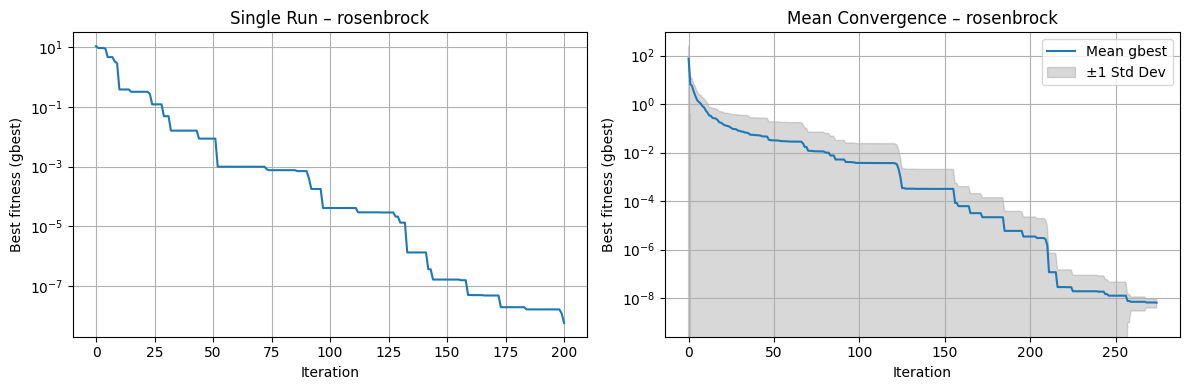


Function: rastrigin, Dimensions: 2, Runs: 30, Local: False
→ mean: 4.796e-05, std: 2.972e-05, best: 0.000e+00, worst: 9.799e-05, success_rate: 100.00, time: 0.68s


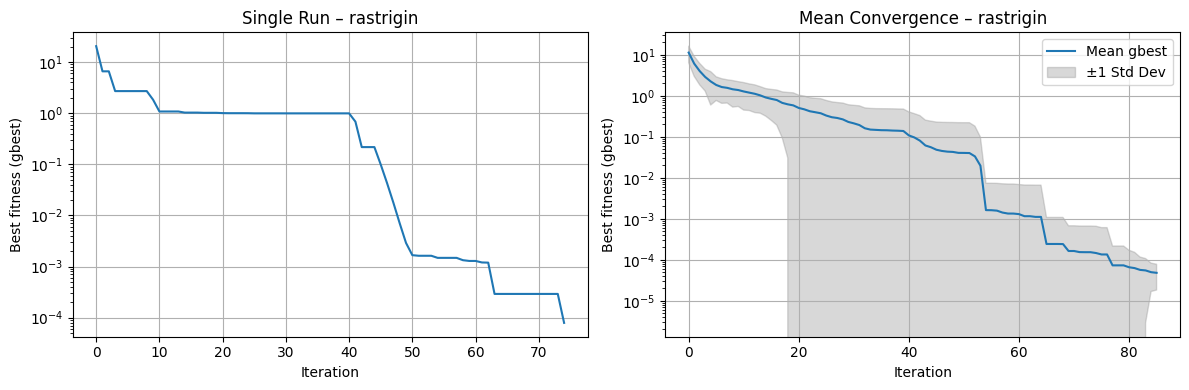


Function: ackley, Dimensions: 2, Runs: 30, Local: False
→ mean: 6.516e-05, std: 2.665e-05, best: 1.013e-05, worst: 1.000e-04, success_rate: 100.00, time: 1.19s


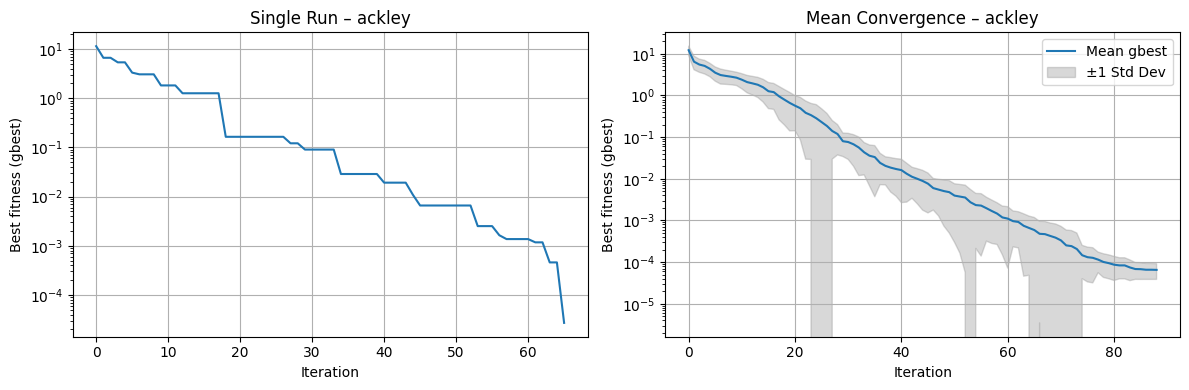

C:\Users\Cemal\AppData\Local\Temp\ipykernel_21144\3208322258.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


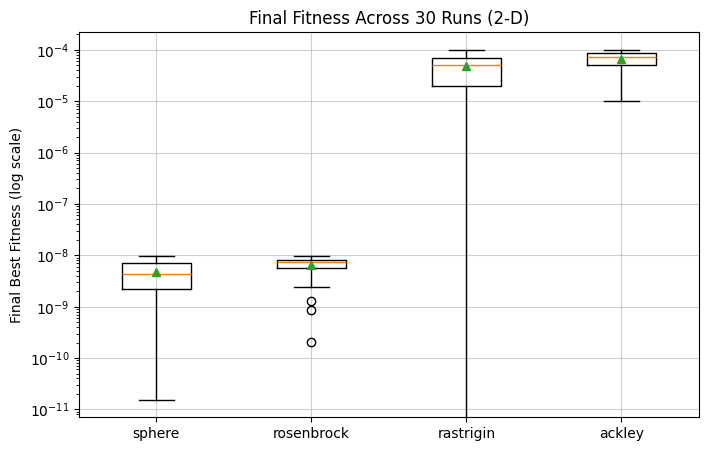

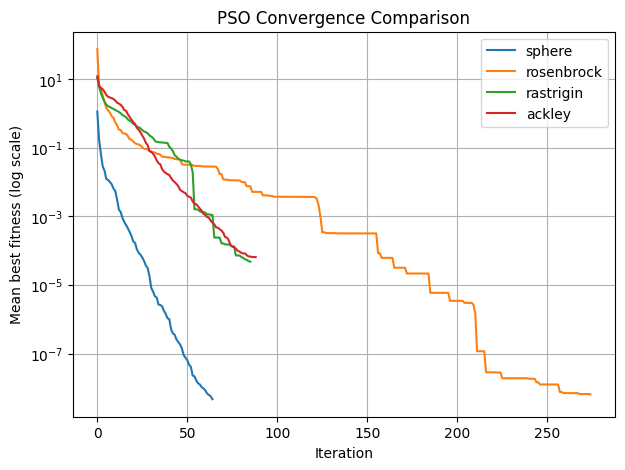





Function: sphere, Dimensions: 10, Runs: 30, Local: False
→ mean: 7.918e-09, std: 1.755e-09, best: 3.162e-09, worst: 9.993e-09, success_rate: 100.00, time: 2.53s


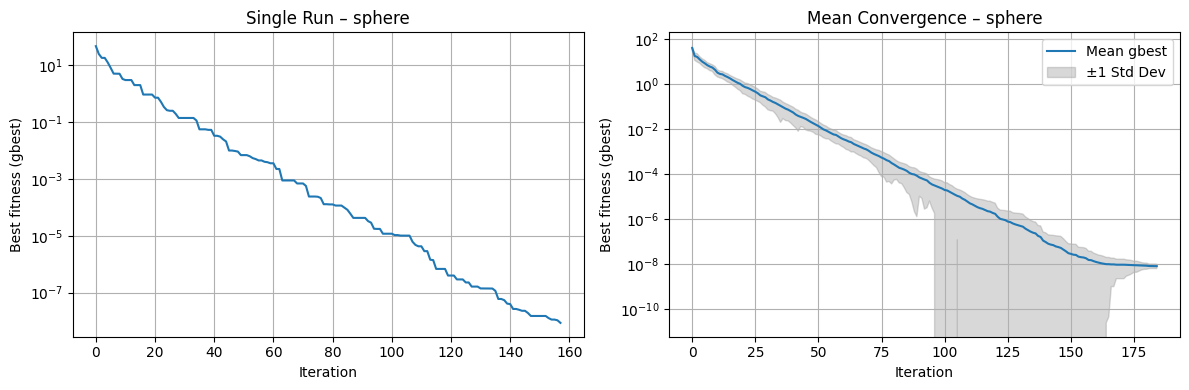


Function: rosenbrock, Dimensions: 10, Runs: 30, Local: False
→ mean: 3.983e+01, std: 1.785e+02, best: 6.811e-02, worst: 9.985e+02, success_rate: 0.00, time: 8.62s


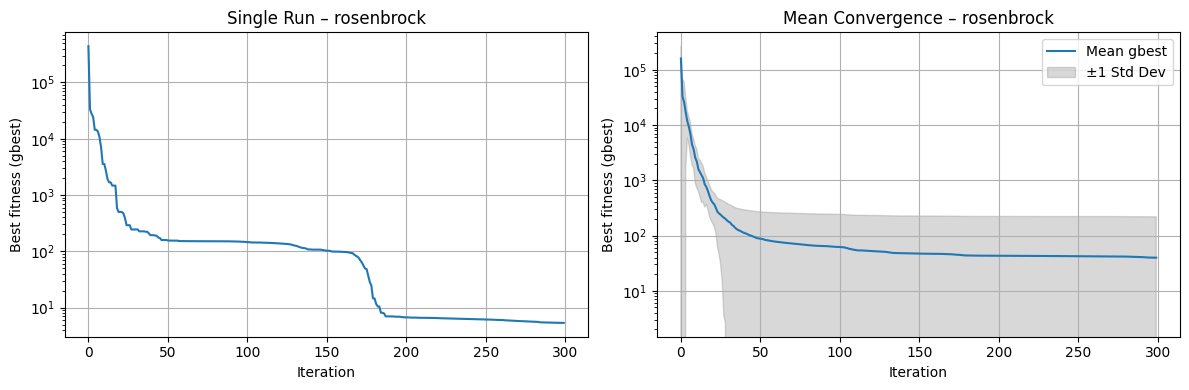


Function: rastrigin, Dimensions: 10, Runs: 30, Local: False
→ mean: 8.082e+00, std: 3.330e+00, best: 2.985e+00, worst: 1.492e+01, success_rate: 0.00, time: 5.84s


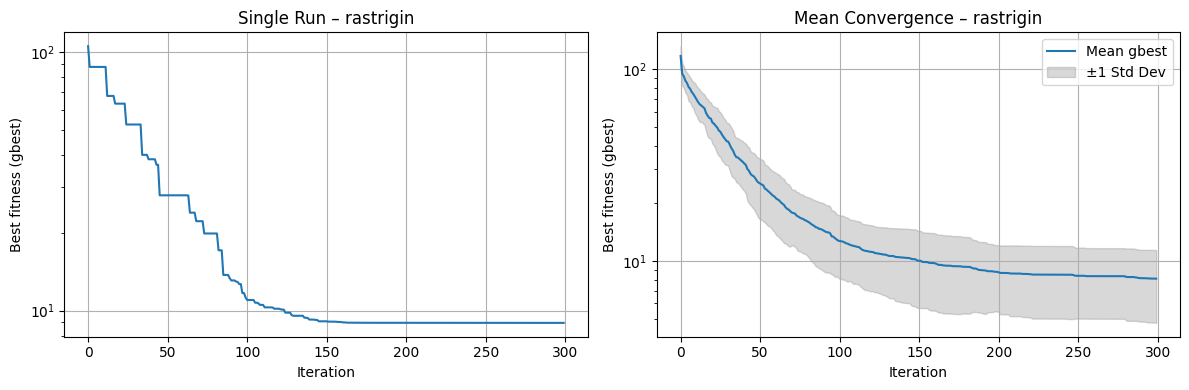


Function: ackley, Dimensions: 10, Runs: 30, Local: False
→ mean: 5.496e-02, std: 2.955e-01, best: 7.428e-05, worst: 1.646e+00, success_rate: 96.67, time: 4.24s


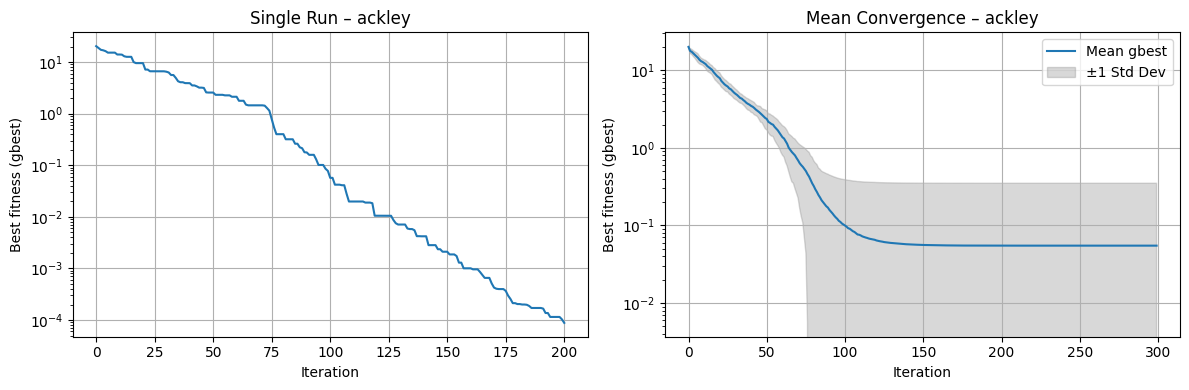

C:\Users\Cemal\AppData\Local\Temp\ipykernel_21144\3208322258.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


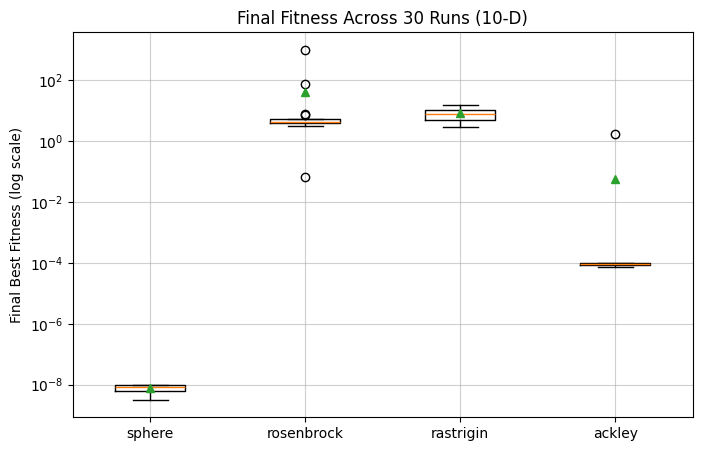

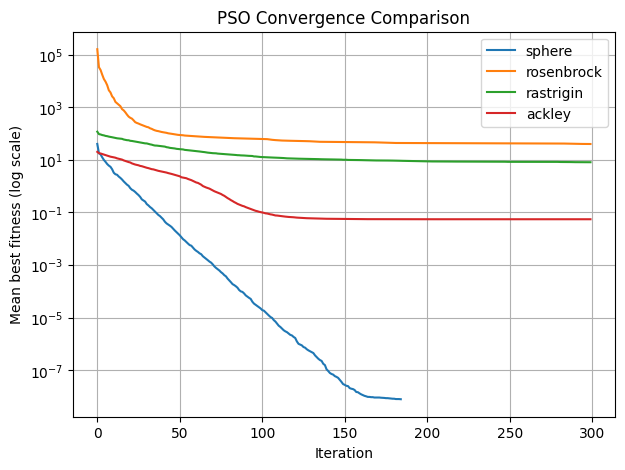





Function: sphere, Dimensions: 30, Runs: 30, Local: False
→ mean: 7.811e-06, std: 2.600e-05, best: 6.733e-08, worst: 1.460e-04, success_rate: 0.00, time: 15.15s


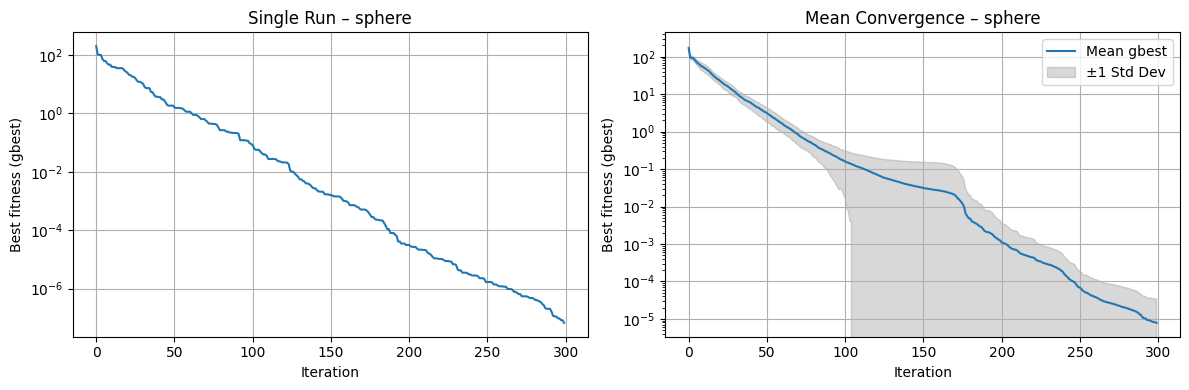


Function: rosenbrock, Dimensions: 30, Runs: 30, Local: False
→ mean: 8.775e+03, std: 1.886e+04, best: 2.091e+01, worst: 5.554e+04, success_rate: 0.00, time: 36.28s


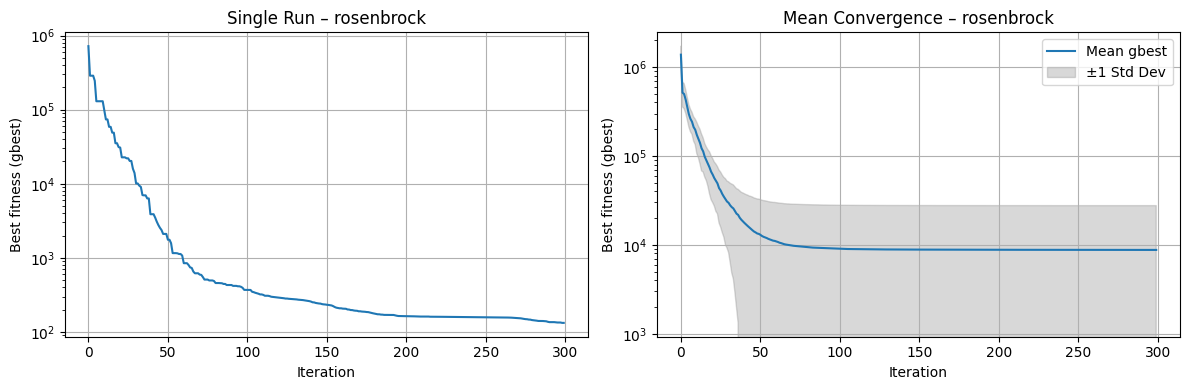


Function: rastrigin, Dimensions: 30, Runs: 30, Local: False
→ mean: 8.605e+01, std: 2.142e+01, best: 5.473e+01, worst: 1.534e+02, success_rate: 0.00, time: 16.11s


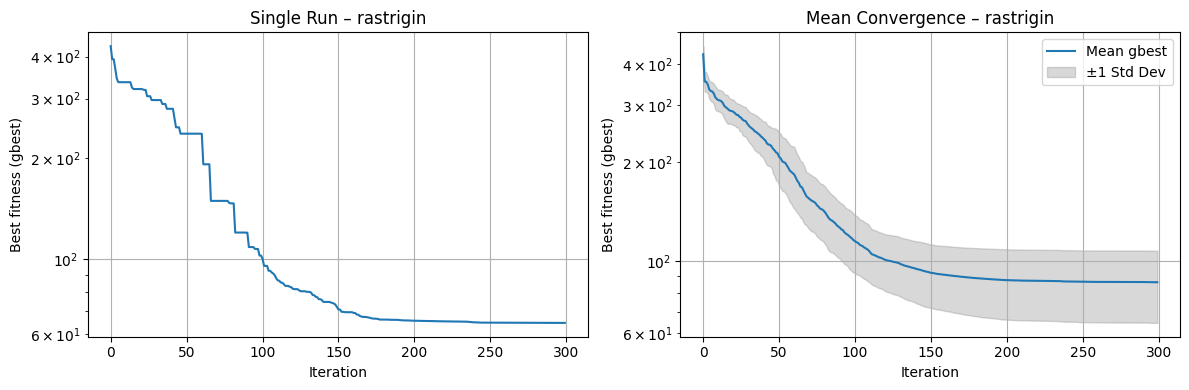


Function: ackley, Dimensions: 30, Runs: 30, Local: False
→ mean: 1.893e+00, std: 9.460e-01, best: 1.063e-02, worst: 3.734e+00, success_rate: 0.00, time: 17.36s


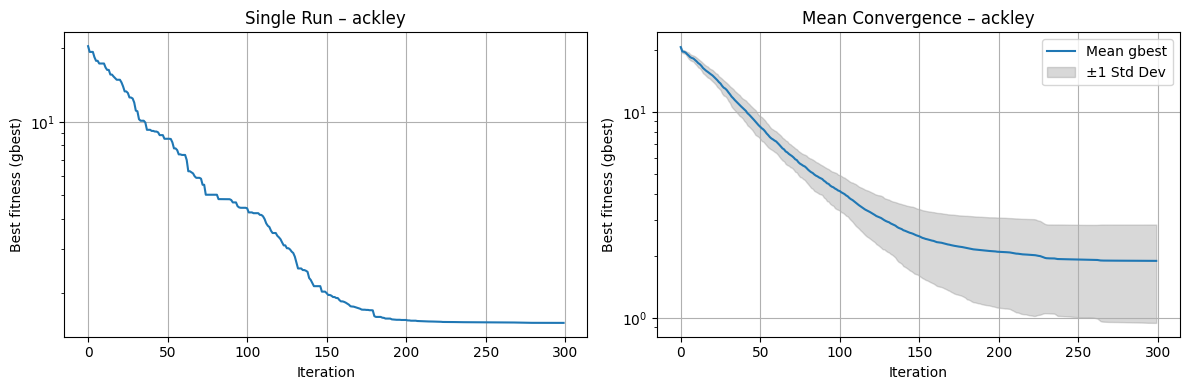

C:\Users\Cemal\AppData\Local\Temp\ipykernel_21144\3208322258.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


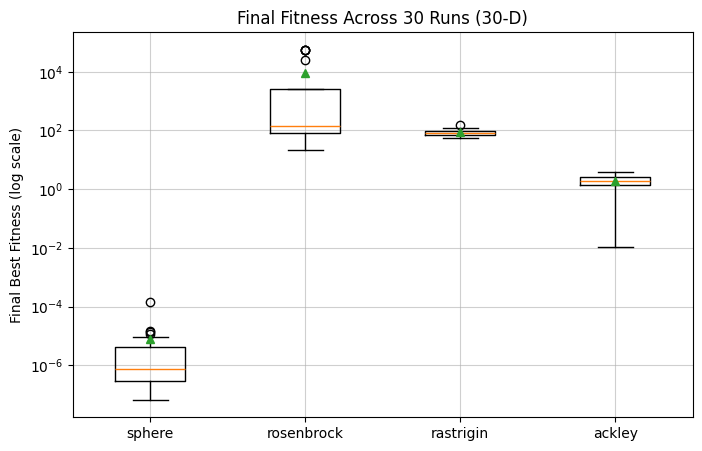

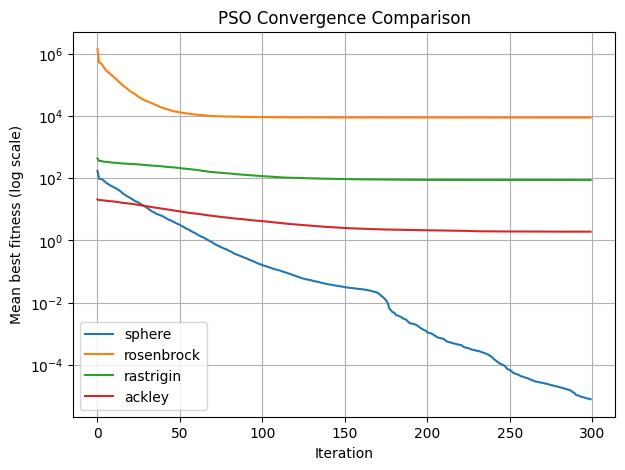

In [19]:
for num_dimensions in [2, 10, 30]:
  results = run_experimental(num_dimensions=num_dimensions, local=False)
  plot_final_fitness_boxplots(results, dimensions=num_dimensions)
  compare_functions(results, dimensions=num_dimensions,functions=["sphere", "rosenbrock", "rastrigin", "ackley"])
  print("\n\n")

### Compare local best & global best

Comparing lbest vs gbest on ackley...


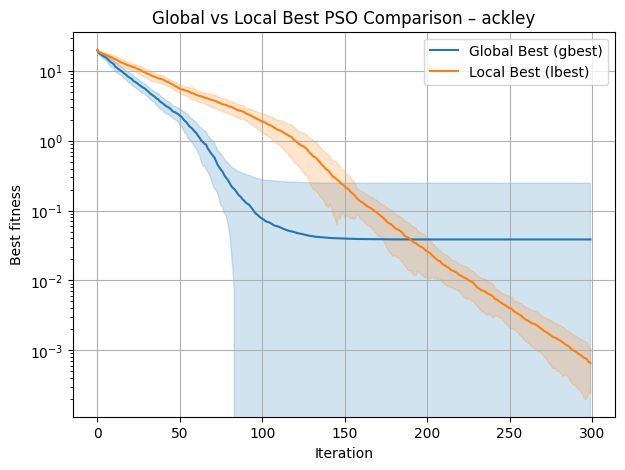

In [20]:
bounds = np.array([(-32.768, 32.768) for _ in range(10)])
compare_lbest_gbest(ackley, bounds, num_runs=30)

### Perform parameter study

In [21]:
np.random.seed(42)
num_dimensions = 10
bounds = [(-5.12, 5.12)]*num_dimensions
configs = [(0.7, 1.5, 1.5), (0.4, 2.0, 2.0), (0.9, 1.0, 1.0), (0.7, 2.0, 1.0), (0.7, 1.0, 2.0)]

param_results = parameter_study([sphere, rosenbrock, rastrigin, ackley], configs, num_dimensions)

for func_name, res in param_results.items():
    print(f"\n--- {func_name.upper()} ---")
    df = pd.DataFrame(res)
    print(df.to_string(index=False, float_format=lambda x: f"{x:.3e}"))


Parameter Study – sphere (n=10)

Parameter Study – rosenbrock (n=10)

Parameter Study – rastrigin (n=10)

Parameter Study – ackley (n=10)

--- SPHERE ---
    omega        c1        c2      mean       std      best     worst
7.000e-01 1.500e+00 1.500e+00 8.299e-09 1.531e-09 3.571e-09 9.990e-09
4.000e-01 2.000e+00 2.000e+00 8.381e-09 1.081e-09 5.917e-09 9.917e-09
9.000e-01 1.000e+00 1.000e+00 1.999e-04 1.436e-04 2.133e-05 5.230e-04
7.000e-01 2.000e+00 1.000e+00 7.748e-09 2.080e-09 2.573e-09 9.996e-09
7.000e-01 1.000e+00 2.000e+00 7.663e-09 1.840e-09 3.542e-09 9.980e-09

--- ROSENBROCK ---
    omega        c1        c2      mean       std      best     worst
7.000e-01 1.500e+00 1.500e+00 7.956e+00 2.004e+01 9.641e-03 1.152e+02
4.000e-01 2.000e+00 2.000e+00 1.247e+01 2.366e+01 4.571e-01 9.407e+01
9.000e-01 1.000e+00 1.000e+00 1.699e+02 4.988e+02 3.171e+00 2.506e+03
7.000e-01 2.000e+00 1.000e+00 6.824e+00 1.671e+01 5.604e-01 9.635e+01
7.000e-01 1.000e+00 2.000e+00 3.544e+02 8.452e+02 1.041

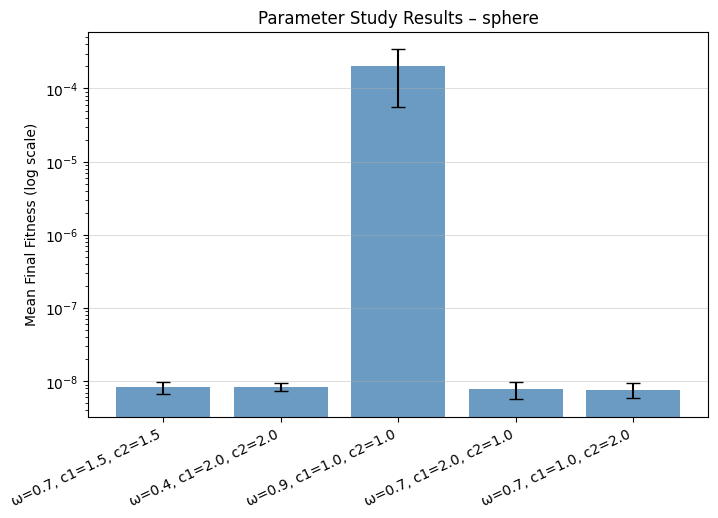

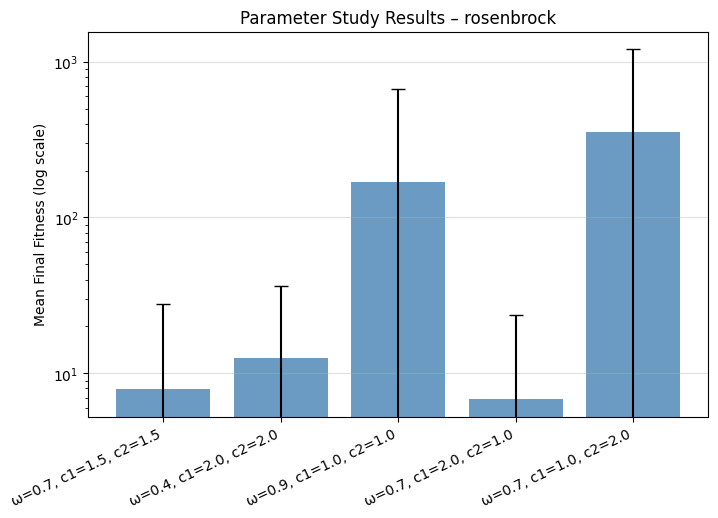

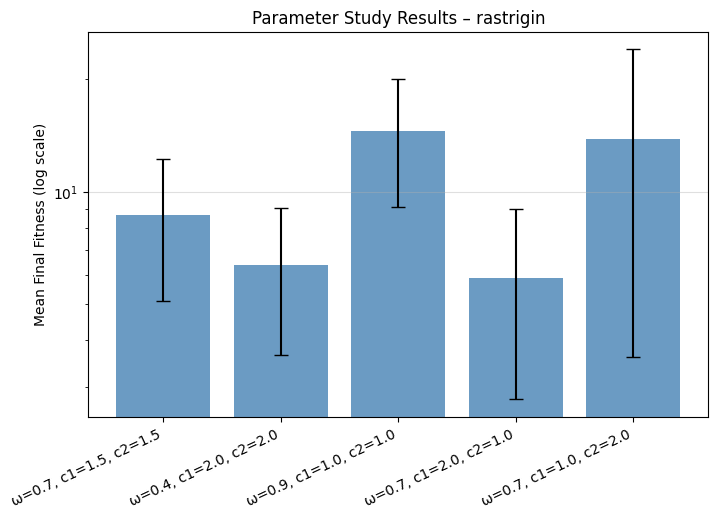

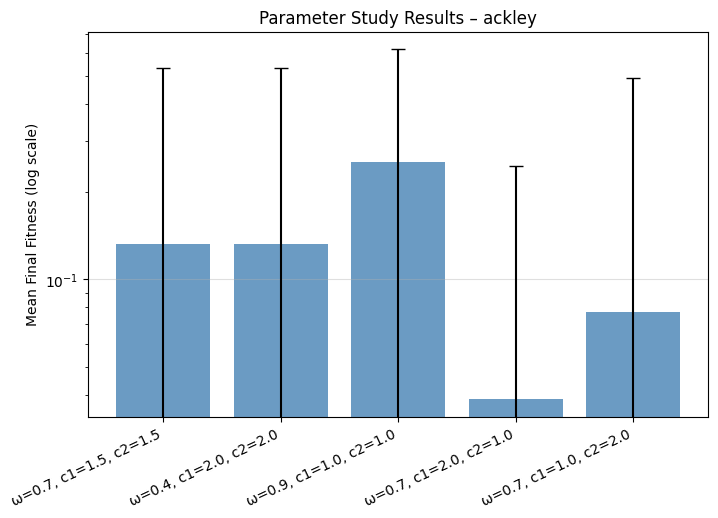

In [22]:
plot_parameter_study(param_results, output_dir="plots")